In [30]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm


In [31]:
ivt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0105_m6Afinal/pileup_strid.npz.genomic.pkl"
ivt_df = pd.read_pickle(ivt_df)
ivt_df = ivt_df[ivt_df["count_all"]>=20]
print(ivt_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         3  0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         3  0.069310   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         3  0.030752   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         3 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         3 -0.000000   
...                          ...         ...     ...       ...       ...   
chrY:-:304883      chrY:-:304883    GTPBP6_1    True         7  0.000000   
chrY:-:304884      chrY:-:304884    GTPBP6_1    True         7  0.000000   
chrY:-:304885      chrY:-:304885    GTPBP6_1    True         7 -0.000000   
chrY:-:304902      chrY:-:304902    GTPBP6_1    True         7  0.000000   
chrY:-:304923      chrY:-:304923    GTPBP6_1    True         7 -0.000000   

           

In [32]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
hek_df = pd.read_pickle(hek_df)
hek_df = hek_df[hek_df["count_all"]>=20]
print(hek_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         3 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         3  0.016154   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         3 -0.000000   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         3 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         3  0.023575   
...                          ...         ...     ...       ...       ...   
chrY:-:341387      chrY:-:341387   PPP2R3B_1    True         8  0.000000   
chrY:-:341388      chrY:-:341388   PPP2R3B_1    True         8 -0.000000   
chrY:-:341389      chrY:-:341389   PPP2R3B_1    True         7  0.000000   
chrY:-:341391      chrY:-:341391   PPP2R3B_1    True         8  0.000000   
chrY:-:341395      chrY:-:341395   PPP2R3B_1    True         8  0.000000   

           

In [33]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.genomic.pkl"
hela_df = pd.read_pickle(hela_df)
hela_df = hela_df[hela_df["count_all"]>=20]
print(hela_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000682  chr10:+:1000682      GTPBP4    True         3  0.013685   
chr10:+:1000684  chr10:+:1000684      GTPBP4    True         3 -0.000000   
chr10:+:1000686  chr10:+:1000686      GTPBP4    True         3 -0.000000   
chr10:+:1000695  chr10:+:1000695      GTPBP4    True         3 -0.000000   
chr10:+:1000702  chr10:+:1000702      GTPBP4    True         3  0.011464   
...                          ...         ...     ...       ...       ...   
chrY:-:318659      chrY:-:318659    GTPBP6_1    True         4  0.000000   
chrY:-:318662      chrY:-:318662    GTPBP6_1    True         4 -0.000000   
chrY:-:318678      chrY:-:318678    GTPBP6_1    True         4 -0.000000   
chrY:-:318708      chrY:-:318708    GTPBP6_1    True         4 -0.000000   
chrY:-:318762      chrY:-:318762    GTPBP6_1    True         4 -0.000000   

           

In [34]:
hek_df.reset_index(drop=True, inplace=True)
hela_df.reset_index(drop=True, inplace=True)
ivt_df.reset_index(drop=True, inplace=True)

In [35]:
dorado_ivt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")
dorado_ivt = dorado_ivt[dorado_ivt["count_dom"] >= 20]
print(dorado_ivt)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.015152        132    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.013889        144    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.028777        139    True
chr10:+:1000694  chr10:+:1000694      GTPBP4  0.000000        148    True
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.007353        136    True
...                          ...         ...       ...        ...     ...
chrY:-:304782      chrY:-:304782    GTPBP6_1  0.000000         20    True
chrY:-:304794      chrY:-:304794    GTPBP6_1  0.050000         20    True
chrY:-:304809      chrY:-:304809    GTPBP6_1  0.000000         20    True
chrY:-:304810      chrY:-:304810    GTPBP6_1  0.047619         21    True
chrY:-:304848      chrY:-:304848    GTPBP6_1  0.000000         20    True

[3506771 rows x 5 columns]


In [36]:
dorado_mrna = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")
dorado_mrna = dorado_mrna[dorado_mrna["count_dom"] >= 20]
print(dorado_mrna)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.008457        473    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.002024        494    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017241        464    True
chr10:+:1000694  chr10:+:1000694      GTPBP4  0.006061        495    True
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.002083        480    True
...                          ...         ...       ...        ...     ...
chrY:-:340778      chrY:-:340778   PPP2R3B_1  0.050000         20    True
chrY:-:340934      chrY:-:340934   PPP2R3B_1  0.050000         20    True
chrY:-:341310      chrY:-:341310   PPP2R3B_1  0.000000         20    True
chrY:-:341367      chrY:-:341367   PPP2R3B_1  0.050000         20    True
chrY:-:341379      chrY:-:341379   PPP2R3B_1  0.050000         20    True

[11063743 rows x 5 columns]


In [37]:
df_m6anet_ivt = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0105/gene_df.pkl"
df_m6anet_cell = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/gene_df.pkl"

df_m6anet_ivt = pd.read_pickle(df_m6anet_ivt)
df_m6anet_cell = pd.read_pickle(df_m6anet_cell)

df_m6anet_ivt = df_m6anet_ivt[df_m6anet_ivt["count_dom"] >= 20]
df_m6anet_cell = df_m6anet_cell[df_m6anet_cell["count_dom"] >= 20]

print(df_m6anet_ivt)
print(df_m6anet_cell)


                       genome_id gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                     
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.000000  0.055526         79   
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.120000  0.283432         75   
chr10:+:1000722  chr10:+:1000722      GTPBP4  0.064935  0.182098         77   
chr10:+:1000831  chr10:+:1000831      GTPBP4  0.095238  0.307818         84   
chr10:+:1000842  chr10:+:1000842      GTPBP4  0.000000  0.131288         78   
...                          ...         ...       ...       ...        ...   
chrX:-:8530670    chrX:-:8530670       ANOS1  0.000000  0.006678         30   
chrX:-:8530819    chrX:-:8530819       ANOS1  0.200000  0.518624         25   
chrX:-:8530830    chrX:-:8530830       ANOS1  0.115385  0.391773         26   
chrX:-:8530974    chrX:-:8530974       ANOS1  0.000000  0.087055         23   
chrX:-:8530991    chrX:-:8530991       ANOS1  0.0000

In [38]:
hek_depth = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.filtered.pkl")
count_hek = len(hek_depth[hek_depth["depth"]>=20])
print(count_hek)

20284907


In [39]:
ivt_depth = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/reference_test/dorado_output.pileup.filtered.pkl")
count_ivt = len(ivt_depth[ivt_depth["depth"]>=20])
print(count_ivt)

3940090


In [40]:
def estimate_fdr_fpr(dorado_mrna, dorado_ivt, airna_mrna, airna_ivt, m6anet_mrna, m6anet_ivt):
    threshold = np.arange(0.0, 3.0, 0.01)
    dorado_fdr_list = []
    airna_fdr_list = []
    dorado_fpr_list = []
    airna_fpr_list = []
    m6anet_fdr_list = []
    m6anet_fpr_list = []
    
    dorado_mrna = np.sort(dorado_mrna["dom"].values)
    dorado_ivt = np.sort(dorado_ivt["dom"].values)
    airna_mrna = np.sort(airna_mrna["pm6a"].values)
    airna_ivt = np.sort(airna_ivt["pm6a"].values)
    m6anet_mrna = np.sort(m6anet_mrna["pm6a"].values)
    m6anet_ivt = np.sort(m6anet_ivt["pm6a"].values)
    
    for t in threshold:
        dorado_ivt_positive_frac = np.sum(dorado_ivt >= t) / count_ivt
        dorado_mrna_positive_frac = np.sum(dorado_mrna >= t) / count_hek
        airna_ivt_positive_frac = np.sum(airna_ivt >= t) / count_ivt
        airna_mrna_positive_frac = np.sum(airna_mrna >= t) / count_hek
        m6anet_ivt_positive_frac = np.sum(m6anet_ivt >= t) / count_ivt
        m6anet_mrna_positive_frac = np.sum(m6anet_mrna >= t) / count_hek
        dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)
        airna_fdr_list.append(airna_ivt_positive_frac / airna_mrna_positive_frac)
        dorado_fpr_list.append(dorado_ivt_positive_frac)
        airna_fpr_list.append(airna_ivt_positive_frac)
        m6anet_fdr_list.append(m6anet_ivt_positive_frac / m6anet_mrna_positive_frac)
        m6anet_fpr_list.append(m6anet_ivt_positive_frac)
        
    df = pd.DataFrame({"dorado_fdr": dorado_fdr_list, "airna_fdr": airna_fdr_list, "dorado_fpr": dorado_fpr_list, "airna_fpr": airna_fpr_list, "threshold": threshold, "m6anet_fdr": m6anet_fdr_list, "m6anet_fpr": m6anet_fpr_list})
    
    return df

In [41]:
df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, hek_df, ivt_df, df_m6anet_cell, df_m6anet_ivt)
df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']] = np.clip(df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']], 0, 1)
print(df)

/tmp/ipykernel_9348/866712976.py:28: RuntimeWarning: invalid value encountered in scalar divide
  m6anet_fdr_list.append(m6anet_ivt_positive_frac / m6anet_mrna_positive_frac)
/tmp/ipykernel_9348/866712976.py:24: RuntimeWarning: invalid value encountered in scalar divide
  dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)


     dorado_fdr  airna_fdr  dorado_fpr  airna_fpr  threshold  m6anet_fdr  \
0           1.0   1.000000    0.890023   0.950026       0.00         1.0   
1           1.0   0.949150    0.512081   0.105042       0.01         1.0   
2           1.0   0.998235    0.438153   0.087361       0.02         1.0   
3           1.0   1.000000    0.362043   0.073415       0.03         1.0   
4           1.0   1.000000    0.294348   0.062347       0.04         1.0   
..          ...        ...         ...        ...        ...         ...   
295         NaN   0.000000    0.000000   0.000000       2.95         NaN   
296         NaN   0.000000    0.000000   0.000000       2.96         NaN   
297         NaN   0.000000    0.000000   0.000000       2.97         NaN   
298         NaN   0.000000    0.000000   0.000000       2.98         NaN   
299         NaN   0.000000    0.000000   0.000000       2.99         NaN   

     m6anet_fpr  
0      0.017508  
1      0.017045  
2      0.016346  
3      0.015542

In [42]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'log FDR vs. Threshold')

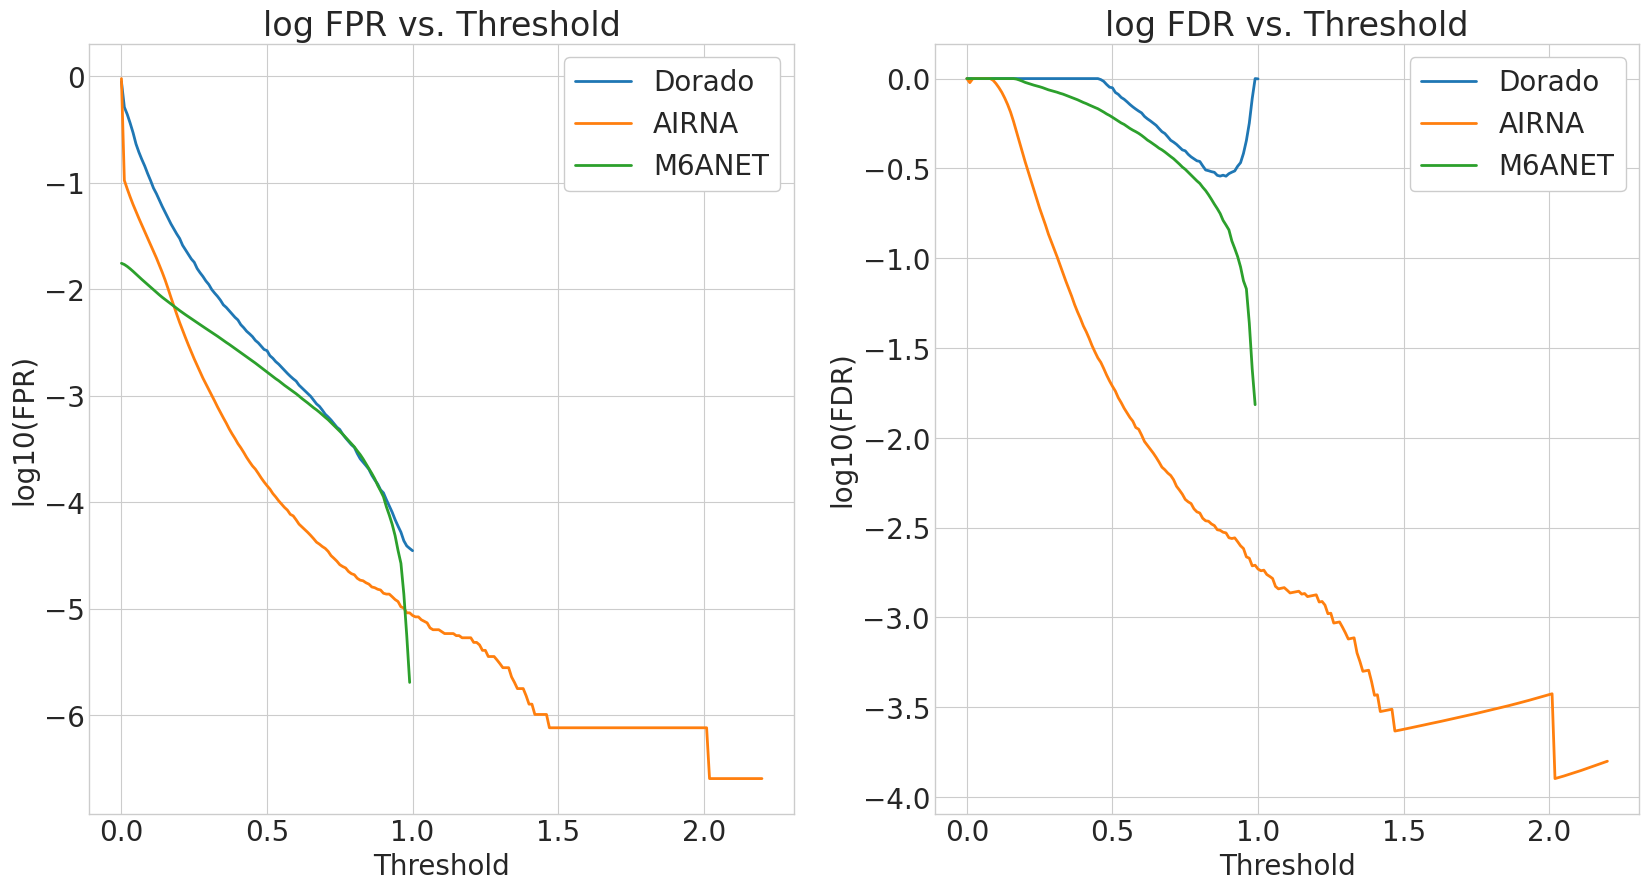

In [43]:

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

## plot 1. log10(FPR)
axes[0].plot(df["threshold"], np.log10(df["dorado_fpr"]), label = "Dorado")
axes[0].plot(df["threshold"], np.log10(df["airna_fpr"]), label = "AIRNA")
axes[0].plot(df["threshold"], np.log10(df["m6anet_fpr"]), label = "M6ANET")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("log10(FPR)")
axes[0].legend()
axes[0].set_title("log FPR vs. Threshold")

## plot 2. FDR
axes[1].plot(df["threshold"], np.log10(df["dorado_fdr"]), label = "Dorado")
axes[1].plot(df["threshold"], np.log10(df["airna_fdr"] ), label = "AIRNA")
axes[1].plot(df["threshold"], np.log10(df["m6anet_fdr"]), label = "M6ANET")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("log10(FDR)")
axes[1].legend()
axes[1].set_title("log FDR vs. Threshold")




In [44]:
## Find Threshold for 0.05 and 0.01 FDR

thr_005 = df[df["airna_fdr"]<=0.05]["threshold"].min()
thr_001 = df[df["airna_fdr"]<=0.01]["threshold"].min()
thr_0001 = df[df["airna_fdr"]<=0.001]["threshold"].min()

print(thr_005, thr_001, thr_0001)

0.39 0.61 1.26


In [45]:
df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, hela_df, ivt_df, df_m6anet_cell, df_m6anet_ivt)
df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']] = np.clip(df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']], 0, 1)
thr_005 = df[df["airna_fdr"]<=0.05]["threshold"].min()
thr_001 = df[df["airna_fdr"]<=0.01]["threshold"].min()
thr_0001 = df[df["airna_fdr"]<=0.001]["threshold"].min()

print(thr_005, thr_001, thr_0001)

/tmp/ipykernel_9348/866712976.py:28: RuntimeWarning: invalid value encountered in scalar divide
  m6anet_fdr_list.append(m6anet_ivt_positive_frac / m6anet_mrna_positive_frac)
/tmp/ipykernel_9348/866712976.py:24: RuntimeWarning: invalid value encountered in scalar divide
  dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)


0.4 0.64 1.3


In [46]:
ivt_count = len(ivt_df)
mrna_count = len(hek_df)

In [47]:
print(ivt_count)
print(len(dorado_ivt))

3743188
3506771


In [48]:
print(df_m6anet_ivt)

                       genome_id gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                     
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.000000  0.055526         79   
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.120000  0.283432         75   
chr10:+:1000722  chr10:+:1000722      GTPBP4  0.064935  0.182098         77   
chr10:+:1000831  chr10:+:1000831      GTPBP4  0.095238  0.307818         84   
chr10:+:1000842  chr10:+:1000842      GTPBP4  0.000000  0.131288         78   
...                          ...         ...       ...       ...        ...   
chrX:-:8530670    chrX:-:8530670       ANOS1  0.000000  0.006678         30   
chrX:-:8530819    chrX:-:8530819       ANOS1  0.200000  0.518624         25   
chrX:-:8530830    chrX:-:8530830       ANOS1  0.115385  0.391773         26   
chrX:-:8530974    chrX:-:8530974       ANOS1  0.000000  0.087055         23   
chrX:-:8530991    chrX:-:8530991       ANOS1  0.0000

In [49]:
airna_f1_thr = 0.841
dorado_f1_thr = 0.458
m6anet_f1_thr = 0.551

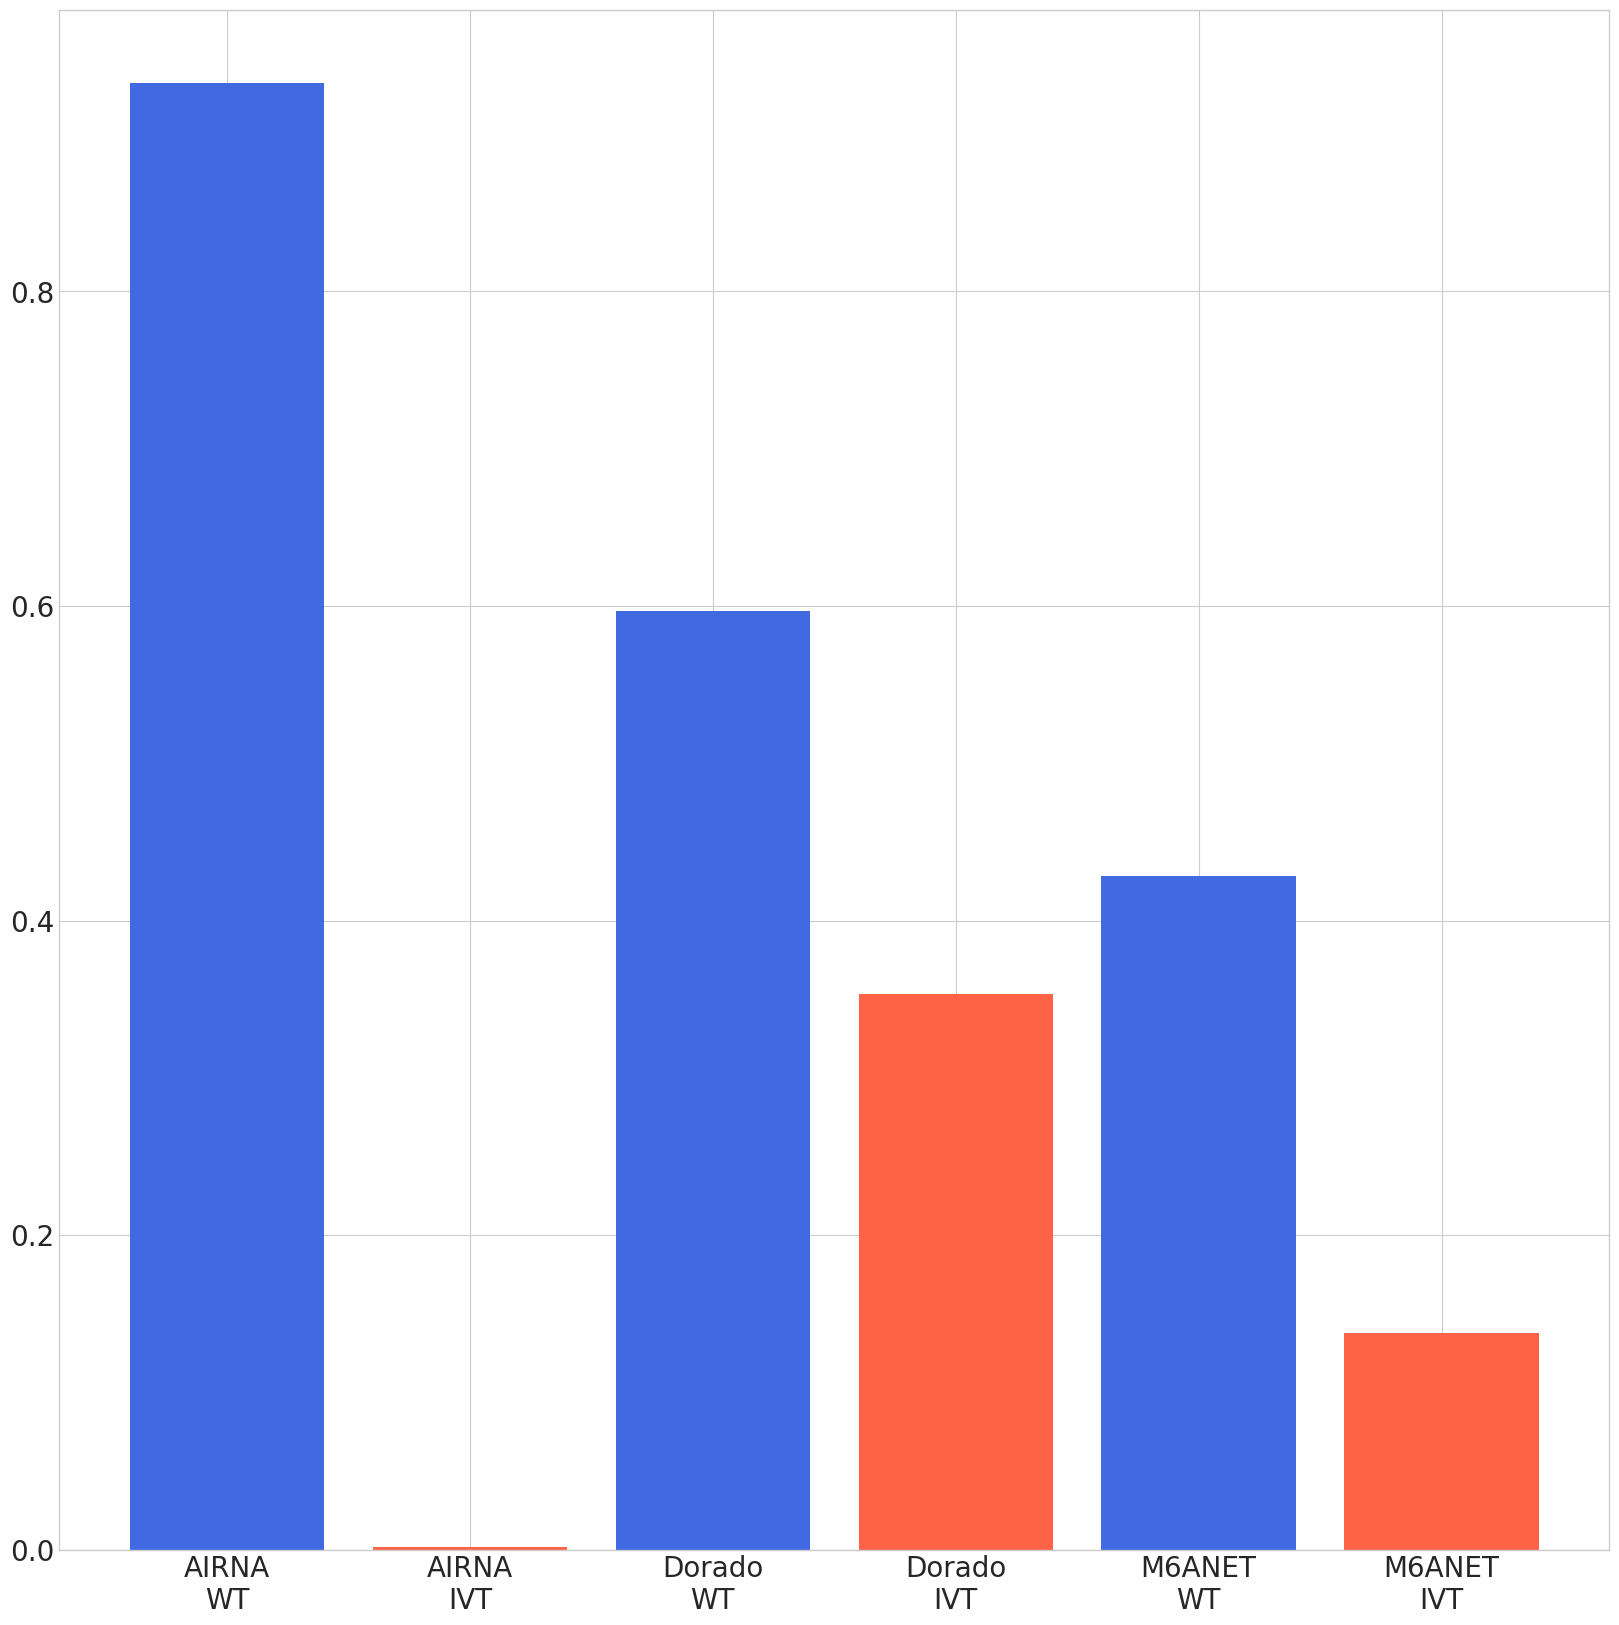

In [50]:
## Plot Bar chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 0, 'edgecolor':'white'}
colors = ['royalblue', 'tomato', ]

data = {}
x=np.sum(hek_df["pm6a"]>=airna_f1_thr)/mrna_count * 100
data["AIRNA\nWT"] = x
x=np.sum(ivt_df["pm6a"]>=airna_f1_thr)/ivt_count * 100
data["AIRNA\nIVT"] = x
x = np.sum(dorado_mrna["dom"]>=dorado_f1_thr)/mrna_count * 100
data["Dorado\nWT"] = x
x = np.sum(dorado_ivt["dom"]>=dorado_f1_thr)/ivt_count * 100
data["Dorado\nIVT"] = x
x = np.sum(df_m6anet_cell["pm6a"]>=m6anet_f1_thr)/mrna_count * 100
data["M6ANET\nWT"] = x
x = np.sum(df_m6anet_ivt["pm6a"]>=m6anet_f1_thr)/ivt_count * 100
data["M6ANET\nIVT"] = x
ax.bar(data.keys(), data.values(), color=colors)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_ivt.pdf", format="pdf")
plt.show()

In [51]:
print(data)

{'AIRNA\nWT': 0.9323890687691407, 'AIRNA\nIVT': 0.0018433485040024707, 'Dorado\nWT': 0.5964734833230483, 'Dorado\nIVT': 0.353575615224242, 'M6ANET\nWT': 0.42811044803356696, 'M6ANET\nIVT': 0.13774354908169187}


In [52]:
print(np.sum(ivt_df["pm6a"]>=airna_f1_thr))
print(np.sum(dorado_ivt["dom"]>=dorado_f1_thr))
print(np.sum(df_m6anet_ivt["pm6a"]>=m6anet_f1_thr))

69
13235
5156


In [53]:
print(np.sum(hek_df["pm6a"]>=airna_f1_thr))

106988
